# Benchmark Report: MariaDB vs. PostgreSQL

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from preprocess import preprocess

In [2]:
sns.set_style("darkgrid")

In [3]:
preprocess()
CSV_FILE = "../benchmark_results/data.csv"
OUTPUT_DIR = "../benchmark_results/charts"
os.makedirs(OUTPUT_DIR, exist_ok=True)
data = pd.read_csv(CSV_FILE)
mariadb = data[data["database_type"] == "mariadb"]
postgres = data[data["database_type"] == "postgres"]

## 1- Insert

### 1-1 Single Insert

In [4]:
mariadb_single = mariadb[mariadb["test_name"] == "single_insert"].iloc[0]
postgres_single = postgres[postgres["test_name"] == "single_insert"].iloc[0]

| Database   | Iterations   | Total Time (s) | Average (ms) | Median (ms) | P95 (ms) | P99 (ms) | Troughput (ops)  |
| ---------- | ------------ | -------------- | ------------ | ----------- | -------- | -------- | ---------------- |
| MariaDB    | 1000000      | 207.04         | 2.06         | 1.75        | 3.50     | 7.61     | 482.9            |
| PostgreSQL | 1000000      | 246.66         | 2.25         | 2.13        | 3.62     | 6.48     | 405.4            |

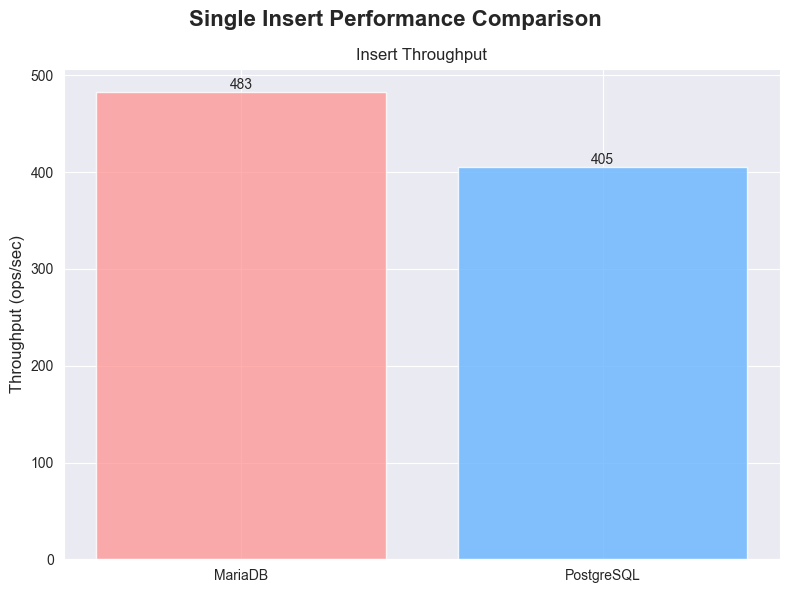

In [6]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
fig.suptitle(
    "Single Insert Performance Comparison", fontsize=16, fontweight="bold"
)
dbs = ["MariaDB", "PostgreSQL"]
times = [mariadb_single["average_time_ms"], postgres_single["average_time_ms"]]
colors = ["#ff9999", "#66b3ff"]

# Throughput
ax2 = axes
throughputs = [
    mariadb_single["throughput_qps"],
    postgres_single["throughput_qps"],
]
bars = ax2.bar(dbs, throughputs, color=colors, alpha=0.8)
ax2.set_ylabel("Throughput (ops/sec)", fontsize=12)
ax2.set_title("Insert Throughput", fontsize=12)

for bar, tput in zip(bars, throughputs):
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{tput:.0f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.savefig(OUTPUT_DIR+"/single_insert.png")
plt.show()

### 1-2 Batch Insert

In [7]:
mariadb_batch = mariadb[mariadb["test_name"].str.contains("batch", na=False)].sort_values("batch_size")
postgres_batch = postgres[postgres["test_name"].str.contains("batch", na=False)].sort_values("batch_size")

| Database   | Batch Size | Iterations   | Total Time (s) | Average (ms) | Median (ms) | P95 (ms) | P99 (ms) | Troughput (ops)  |
| ---------- | ---------- | ------------ | -------------- | ------------ | ----------- | -------- | -------- | ---------------- |
| MariaDB    | 10         | 1000000      | 285.35         | 0.284        | 0.232       | 0.592    | 1.03     | 3504.4           |
| PostgreSQL | 10         | 1000000      | 370.66         | 0.368        | 0.321       | 0.622    | 1.09     | 2697.8           |
|            |            |              |                |              |             |          |          |                  |
| MariaDB    | 100        | 1000000      | 86.12          | 0.086        | 0.075       | 0.119    | 0.18     | 11611.7          |
| PostgreSQL | 100        | 1000000      | 112.77         | 0.112        | 0.100       | 0.0159   | 0.24     | 8867.5           |
|            |            |              |                |              |             |          |          |                  |
| MariaDB    | 1000       | 1000000      | 62.12          | 0.062        | 0.053       | 0.085    | 0.33     | 416096.5         |
| PostgreSQL | 1000       | 1000000      | 79.66          | 0.079        | 0.072       | 0.103    | 0.26     | 12552.4          |
|            |            |              |                |              |             |          |          |                  |
| MariaDB    | 5000       | 1000000      | 67.87          | 0.068        | 0.062       | 0.093    | 0.23     | 14733.0          |
| PostgreSQL | 5000       | 1000000      | 74.07          | 0.074        | 0.071       | 0.096    | 0.12     | 13469.1          |

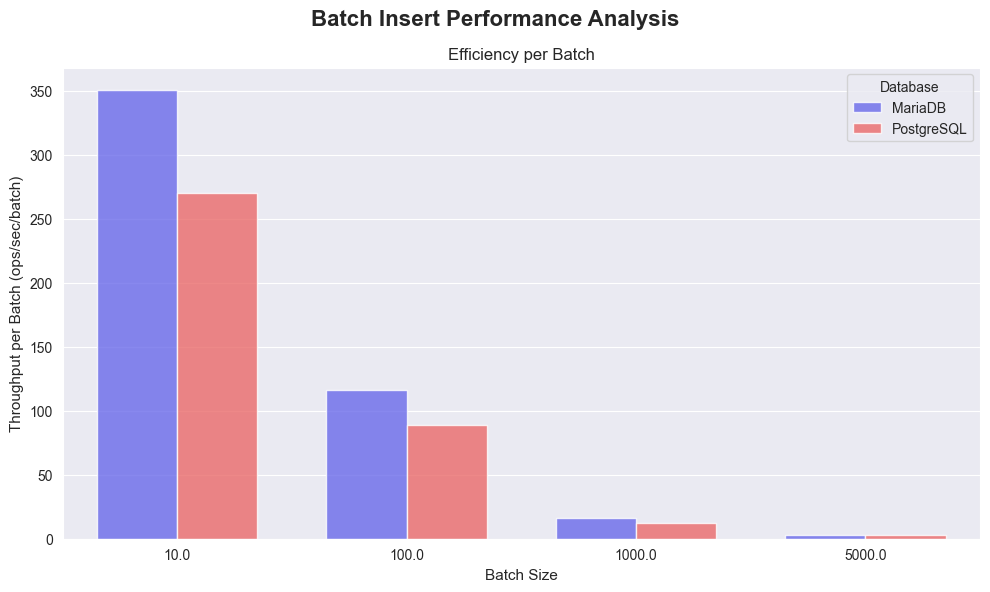

In [9]:
data = []
for batch_size, mariadb_qps, postgres_qps in zip(
    mariadb_batch["batch_size"].values,
    mariadb_batch["throughput_qps"].values,
    postgres_batch["throughput_qps"].values
):
    # MariaDB
    data.append({
        'batch_size': batch_size,
        'database': 'MariaDB',
        'efficiency': mariadb_qps / batch_size
    })
    # PostgreSQL
    data.append({
        'batch_size': batch_size,
        'database': 'PostgreSQL',
        'efficiency': postgres_qps / batch_size
    })

df = pd.DataFrame(data)

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))


# Create the bar plot
sns.barplot(
    data=df,
    x='batch_size',
    y='efficiency',
    hue='database',
    palette=sns.color_palette("seismic", 2),
    alpha=0.8,
    ax=ax,
    width=0.7  # Adjust bar width as needed
)

# Customize the plot
fig.suptitle(
    "Batch Insert Performance Analysis", 
    fontsize=16, 
    fontweight="bold"
)

ax.set_xlabel("Batch Size", fontsize=11)
ax.set_ylabel("Throughput per Batch (ops/sec/batch)", fontsize=11)
ax.set_title("Efficiency per Batch", fontsize=12)

# Adjust legend
ax.legend(title='Database')

plt.tight_layout()
plt.savefig(OUTPUT_DIR+"/batch_insert.png")
plt.show()

### 1-3 Concurrent Insert

In [10]:
mariadb_concurrent = mariadb[mariadb["test_name"].str.contains("concurrent", na=False)].sort_values("concurrent_workers")
postgres_concurrent = postgres[postgres["test_name"].str.contains("concurrent", na=False)].sort_values("concurrent_workers")

| Database | Workers | Iterations | Total Time (s) | Average (ms) | Median (ms) | P95 (ms) | P99 (ms) | Throughput (ops/s) |
|:--------:|:-------:|-----------:|---------------:|-------------:|------------:|---------:|---------:|-------------------:|
| **MariaDB** | 5 | 100,000 | 58.72 | 2.78 | 2.19 | 5.63 | 12.02 | 1,703.1 |
| **PostgreSQL** | 5 | 100,000 | 56.01 | 2.76 | 2.41 | 4.49 | 9.85 | 1,785.4 |
| | | | | | | | | |
| **MariaDB** | 10 | 100,000 | 58.19 | 5.77 | 4.39 | 13.28 | 27.32 | 1,718.4 |
| **PostgreSQL** | 10 | 100,000 | 45.31 | 4.40 | 3.33 | 10.05 | 20.78 | 2,207.2 |
| | | | | | | | | |
| **MariaDB** | 15 | 100,000 | 65.04 | 9.69 | 7.44 | 22.81 | 47.85 | 1,537.4 |
| **PostgreSQL** | 15 | 100,000 | 45.71 | 6.78 | 4.84 | 17.23 | 38.89 | 2,187.5 |
| | | | | | | | | |
| **MariaDB** | 20 | 100,000 | 61.51 | 12.17 | 9.46 | 29.46 | 55.07 | 1,625.8 |
| **PostgreSQL** | 20 | 100,000 | 50.51 | 9.94 | 7.41 | 23.85 | 48.08 | 1,979.6 |

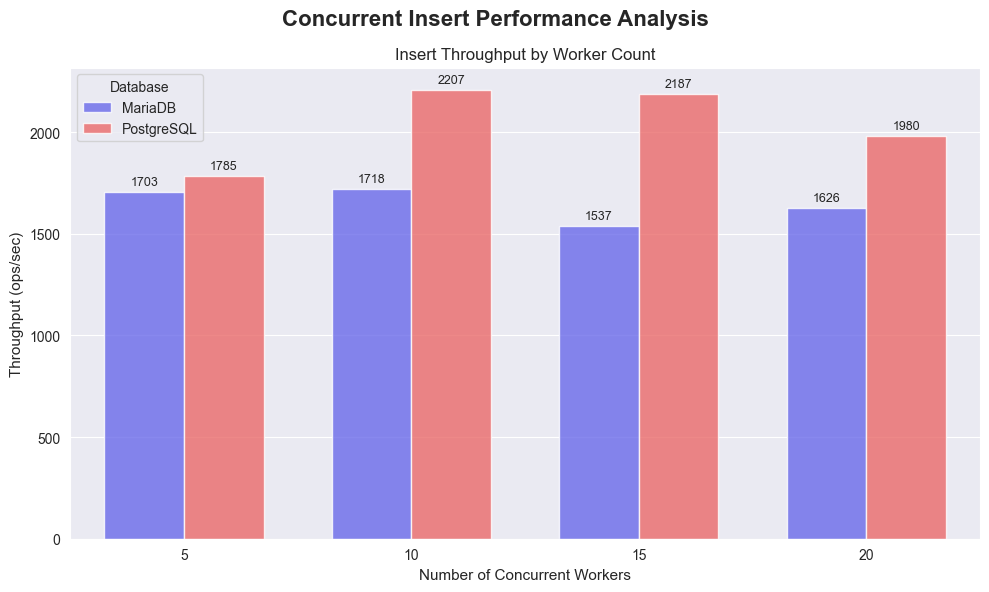

In [11]:
# Extract worker counts from test_name
def extract_workers(test_name):
    return int(test_name.split('_')[-1])

# Make copies and add worker count
mariadb_concurrent = mariadb[mariadb["test_name"].str.contains("concurrent", na=False)].copy()
postgres_concurrent = postgres[postgres["test_name"].str.contains("concurrent", na=False)].copy()

mariadb_concurrent['workers'] = mariadb_concurrent['test_name'].apply(extract_workers)
postgres_concurrent['workers'] = postgres_concurrent['test_name'].apply(extract_workers)

# Sort by workers
mariadb_concurrent = mariadb_concurrent.sort_values('workers')
postgres_concurrent = postgres_concurrent.sort_values('workers')

# Prepare data for seaborn
data = []
for workers, mariadb_qps, postgres_qps in zip(
    mariadb_concurrent["workers"].values,
    mariadb_concurrent["throughput_qps"].values,
    postgres_concurrent["throughput_qps"].values
):
    # MariaDB
    data.append({
        'workers': workers,
        'database': 'MariaDB',
        'throughput': mariadb_qps
    })
    # PostgreSQL
    data.append({
        'workers': workers,
        'database': 'PostgreSQL',
        'throughput': postgres_qps
    })

df = pd.DataFrame(data)

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))


# Create the bar plot
sns.barplot(
    data=df,
    x='workers',
    y='throughput',
    hue='database',
    palette=sns.color_palette("seismic", 2),
    alpha=0.8,
    ax=ax,
    width=0.7
)

# Customize the plot
fig.suptitle(
    "Concurrent Insert Performance Analysis", 
    fontsize=16, 
    fontweight="bold"
)

ax.set_xlabel("Number of Concurrent Workers", fontsize=11)
ax.set_ylabel("Throughput (ops/sec)", fontsize=11)
ax.set_title("Insert Throughput by Worker Count", fontsize=12)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=9)

# Adjust legend
ax.legend(title='Database')

plt.tight_layout()
plt.savefig(OUTPUT_DIR+"/concurrent_insert.png")
plt.show()

## 2- Update

In [12]:
mariadb_update = mariadb[mariadb["test_name"] == "update_row"].iloc[0]
postgres_update = postgres[postgres["test_name"] == "update_row"].iloc[0]

| Database | Iterations | Total Time (s) | Average (ms) | Median (ms) | P95 (ms) | P99 (ms) | Throughput (ops/s) |
|:--------:|-----------:|---------------:|-------------:|------------:|---------:|---------:|-------------------:|
| **MariaDB** | 1,000,000 | 2,022.21 | 2.015 | 1.620 | 3.600 | 10.173 | 494.5 |
| **PostgreSQL** | 1,000,000 | 2,352.96 | 2.344 | 2.057 | 3.628 | 7.000 | 425.0 |

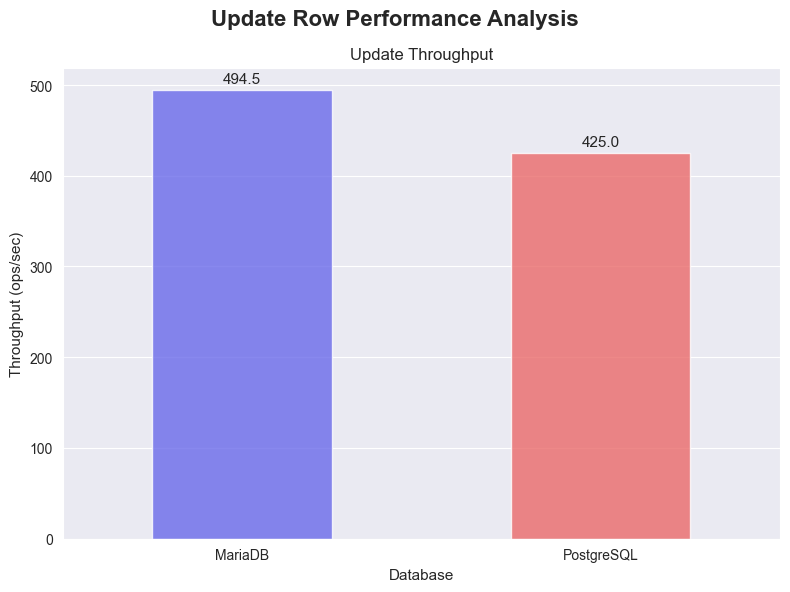

In [13]:
data = [
    {
        'database': 'MariaDB',
        'throughput': mariadb_update['throughput_qps']
    },
    {
        'database': 'PostgreSQL',
        'throughput': postgres_update['throughput_qps']
    }
]

df = pd.DataFrame(data)

# Create throughput chart
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Create the bar plot - fixed warning by assigning x to hue
sns.barplot(
    data=df,
    x='database',
    y='throughput',
    hue='database',  # Assign x variable to hue
    palette=sns.color_palette("seismic", 2),
    alpha=0.8,
    ax=ax,
    width=0.5,
    legend=False  # Remove legend since it's redundant
)

# Customize the plot
fig.suptitle(
    "Update Row Performance Analysis", 
    fontsize=16, 
    fontweight="bold"
)

ax.set_xlabel("Database", fontsize=11)
ax.set_ylabel("Throughput (ops/sec)", fontsize=11)
ax.set_title("Update Throughput", fontsize=12)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR+"/update.png")
plt.show()